# Federated Learning Experimental Study (IID vs Non-IID)

This notebook implements a comparative study of:
- Centralized Learning
- Federated Learning (IID)
- Federated Learning (Non-IID)

We analyze:
- Model accuracy
- Convergence behavior
- Impact of data distribution
- Communication overhead

The goal is to understand how federated learning behaves under realistic conditions.

In [1]:
!pip install tensorflow numpy matplotlib scikit-learn

# Import Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import time

from tensorflow.keras import layers, models, Input

## Data Loading and Preprocessing

We use the MNIST dataset.  
Images are normalized and reshaped for CNN input.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


## Model Architecture

We use a simple CNN for classification.  
The model is intentionally lightweight to focus on training behavior.

In [4]:
def create_model():
    model = models.Sequential([
        Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Centralized Learning (Baseline)

We first train a centralized model using the full dataset.  
This serves as a reference for comparison.

In [5]:
central_model = create_model()

start_time = time.time()

history = central_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

central_time = time.time() - start_time

loss, central_acc = central_model.evaluate(x_test, y_test)

print("\nCentralized Accuracy:", central_acc)
print("Training Time:", central_time)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9591 - loss: 0.1314 - val_accuracy: 0.9839 - val_loss: 0.0559
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9872 - loss: 0.0424 - val_accuracy: 0.9877 - val_loss: 0.0341
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9909 - loss: 0.0293 - val_accuracy: 0.9895 - val_loss: 0.0332
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9924 - loss: 0.0228 - val_accuracy: 0.9909 - val_loss: 0.0275
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9951 - loss: 0.0159 - val_accuracy: 0.9915 - val_loss: 0.0271
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9915 - loss: 0.0271

Centralized Accuracy: 0.9915000200271606
Training Time: 167.68737363815308


## IID Client Simulation

In this step, we split the dataset evenly across clients.

Each client receives a similar distribution of data.
This represents an ideal federated learning scenario.

In [7]:
def create_iid_clients(x, y, num_clients=3):
    indices = np.arange(len(x))
    np.random.shuffle(indices)

    split_indices = np.array_split(indices, num_clients)

    clients = []

    for i, idx in enumerate(split_indices):
        x_c = x[idx]
        y_c = y[idx]

        print(f"Client {i+1} samples:", len(x_c))
        clients.append((x_c, y_c))

    return clients


iid_clients = create_iid_clients(x_train, y_train)

Client 1 samples: 20000
Client 2 samples: 20000
Client 3 samples: 20000


In [8]:
for i, (x_c, y_c) in enumerate(iid_clients):
    unique, counts = np.unique(y_c, return_counts=True)
    print(f"\nClient {i+1} label distribution:")
    print(dict(zip(unique, counts)))


Client 1 label distribution:
{np.uint8(0): np.int64(1971), np.uint8(1): np.int64(2263), np.uint8(2): np.int64(1969), np.uint8(3): np.int64(1957), np.uint8(4): np.int64(1948), np.uint8(5): np.int64(1834), np.uint8(6): np.int64(1951), np.uint8(7): np.int64(2080), np.uint8(8): np.int64(1993), np.uint8(9): np.int64(2034)}

Client 2 label distribution:
{np.uint8(0): np.int64(2017), np.uint8(1): np.int64(2229), np.uint8(2): np.int64(2065), np.uint8(3): np.int64(2039), np.uint8(4): np.int64(1911), np.uint8(5): np.int64(1820), np.uint8(6): np.int64(1972), np.uint8(7): np.int64(2048), np.uint8(8): np.int64(1949), np.uint8(9): np.int64(1950)}

Client 3 label distribution:
{np.uint8(0): np.int64(1935), np.uint8(1): np.int64(2250), np.uint8(2): np.int64(1924), np.uint8(3): np.int64(2135), np.uint8(4): np.int64(1983), np.uint8(5): np.int64(1767), np.uint8(6): np.int64(1995), np.uint8(7): np.int64(2137), np.uint8(8): np.int64(1909), np.uint8(9): np.int64(1965)}


## Federated Training Engine (FedAvg)

We simulate federated learning using:
- Local client training
- Global weight aggregation (FedAvg)

We also track accuracy per round.

In [9]:
def federated_train(clients, rounds=5):
    global_model = create_model()
    global_weights = global_model.get_weights()

    acc_list = []
    loss_list = []

    start_time = time.time()

    for r in range(rounds):
        print(f"\n--- Round {r+1} ---")

        local_weights = []

        for i, (x_c, y_c) in enumerate(clients):
            local_model = create_model()
            local_model.set_weights(global_weights)

            local_model.fit(x_c, y_c, epochs=1, batch_size=32, verbose=0)

            local_weights.append(local_model.get_weights())

            print(f"Client {i+1} trained")

        # FedAvg aggregation
        new_weights = []

        for weights in zip(*local_weights):
            new_weights.append(np.mean(weights, axis=0))

        global_weights = new_weights
        global_model.set_weights(global_weights)

        loss, acc = global_model.evaluate(x_test, y_test, verbose=0)

        acc_list.append(acc)
        loss_list.append(loss)

        print(f"Round {r+1} Accuracy: {acc:.4f}")

    total_time = time.time() - start_time

    print("\nTotal Training Time:", total_time)

    return acc_list, loss_list, total_time

In [10]:
iid_acc, iid_loss, iid_time = federated_train(iid_clients, rounds=5)

print("\nFinal IID Accuracy:", iid_acc[-1])


--- Round 1 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 1 Accuracy: 0.9769

--- Round 2 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 2 Accuracy: 0.9857

--- Round 3 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 3 Accuracy: 0.9891

--- Round 4 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 4 Accuracy: 0.9904

--- Round 5 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 5 Accuracy: 0.9919

Total Training Time: 174.73838138580322

Final IID Accuracy: 0.9919000267982483


## Non-IID Client Simulation

In this setup, each client receives a biased subset of the data.

This simulates real-world conditions where data is not evenly distributed.

In [11]:
def create_noniid_clients(x, y):
    client1_idx = np.where(y < 4)[0]
    client2_idx = np.where((y >= 4) & (y < 7))[0]
    client3_idx = np.where(y >= 7)[0]

    clients = []

    for i, idx in enumerate([client1_idx, client2_idx, client3_idx]):
        x_c = x[idx]
        y_c = y[idx]

        print(f"Client {i+1} samples:", len(x_c))
        clients.append((x_c, y_c))

    return clients


noniid_clients = create_noniid_clients(x_train, y_train)

Client 1 samples: 24754
Client 2 samples: 17181
Client 3 samples: 18065


In [12]:
for i, (x_c, y_c) in enumerate(noniid_clients):
    unique, counts = np.unique(y_c, return_counts=True)
    print(f"\nClient {i+1} label distribution:")
    print(dict(zip(unique, counts)))


Client 1 label distribution:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131)}

Client 2 label distribution:
{np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918)}

Client 3 label distribution:
{np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


In [13]:
noniid_acc, noniid_loss, noniid_time = federated_train(noniid_clients, rounds=5)

print("\nFinal Non-IID Accuracy:", noniid_acc[-1])


--- Round 1 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 1 Accuracy: 0.7337

--- Round 2 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 2 Accuracy: 0.8605

--- Round 3 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 3 Accuracy: 0.9043

--- Round 4 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 4 Accuracy: 0.9315

--- Round 5 ---
Client 1 trained
Client 2 trained
Client 3 trained
Round 5 Accuracy: 0.9403

Total Training Time: 199.47067284584045

Final Non-IID Accuracy: 0.9402999877929688


## Visualization and Analysis

We compare the performance of:
- Centralized Learning
- Federated Learning (IID)
- Federated Learning (Non-IID)

We analyze accuracy trends across training rounds.

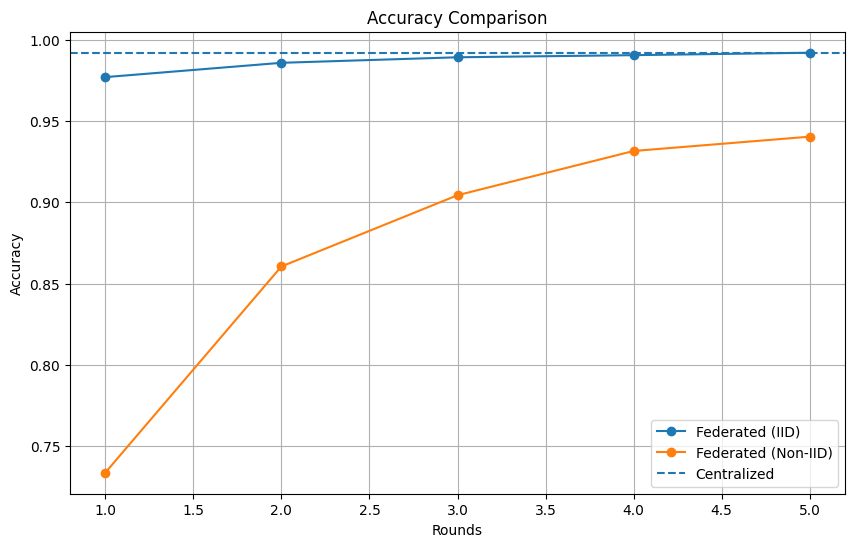

In [14]:
rounds = list(range(1, len(iid_acc)+1))

plt.figure(figsize=(10,6))

plt.plot(rounds, iid_acc, marker='o', label="Federated (IID)")
plt.plot(rounds, noniid_acc, marker='o', label="Federated (Non-IID)")

plt.axhline(y=central_acc, linestyle='--', label="Centralized")

plt.title("Accuracy Comparison")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [15]:
print("Centralized Time:", central_time)
print("IID Federated Time:", iid_time)
print("Non-IID Federated Time:", noniid_time)

Centralized Time: 167.68737363815308
IID Federated Time: 174.73838138580322
Non-IID Federated Time: 199.47067284584045


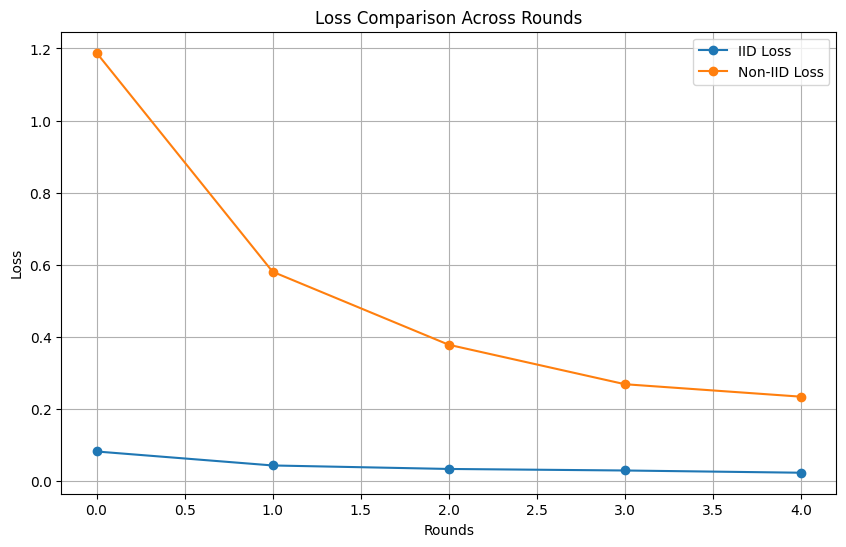

In [16]:
plt.figure(figsize=(10,6))

plt.plot(iid_loss, marker='o', label="IID Loss")
plt.plot(noniid_loss, marker='o', label="Non-IID Loss")

plt.title("Loss Comparison Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

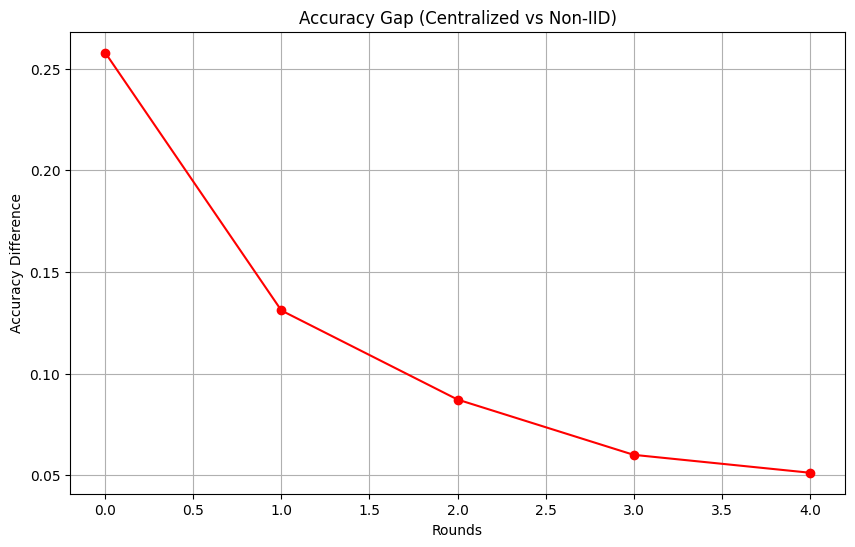

In [17]:
diff = [central_acc - acc for acc in noniid_acc]

plt.figure(figsize=(10,6))

plt.plot(diff, marker='o', color='red')

plt.title("Accuracy Gap (Centralized vs Non-IID)")
plt.xlabel("Rounds")
plt.ylabel("Accuracy Difference")
plt.grid()

plt.show()

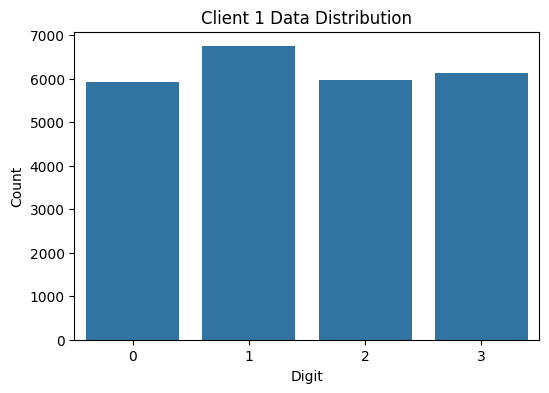

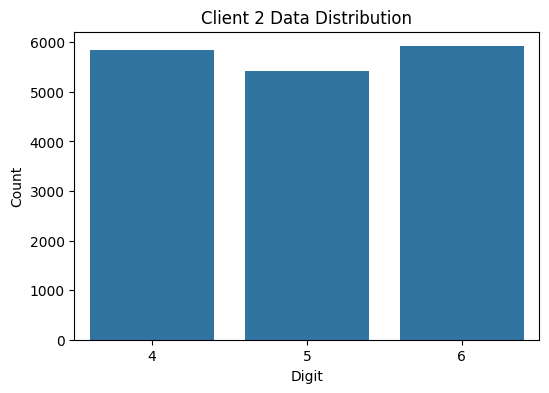

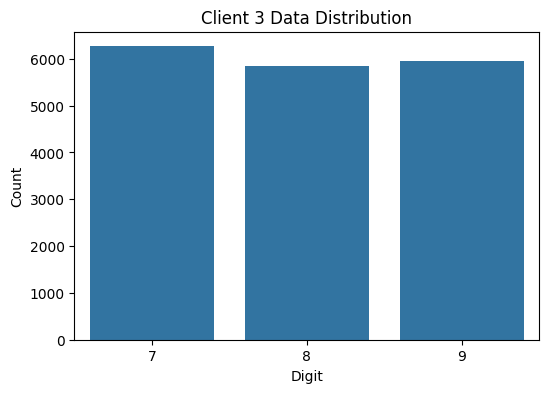

In [18]:
import seaborn as sns

for i, (x_c, y_c) in enumerate(noniid_clients):
    plt.figure(figsize=(6,4))
    sns.countplot(x=y_c)
    plt.title(f"Client {i+1} Data Distribution")
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.show()

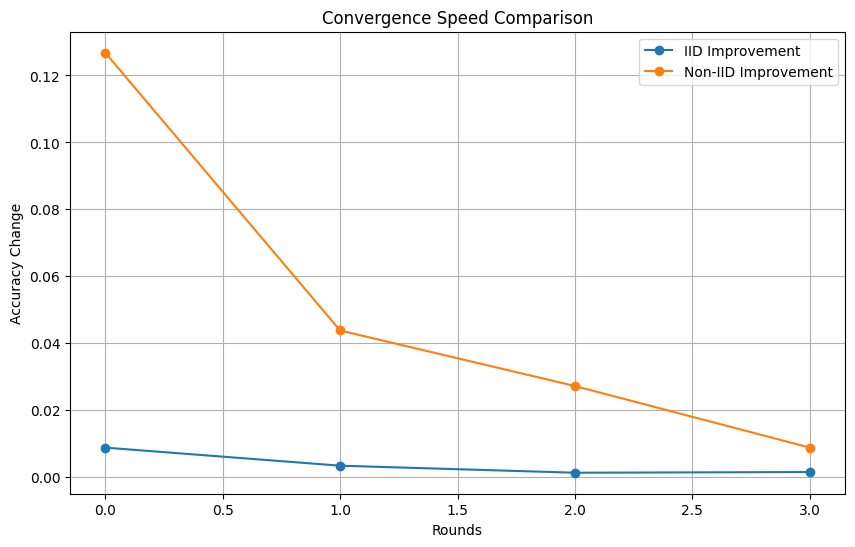

In [19]:
iid_improvement = [iid_acc[i] - iid_acc[i-1] for i in range(1, len(iid_acc))]
noniid_improvement = [noniid_acc[i] - noniid_acc[i-1] for i in range(1, len(noniid_acc))]

plt.figure(figsize=(10,6))

plt.plot(iid_improvement, marker='o', label="IID Improvement")
plt.plot(noniid_improvement, marker='o', label="Non-IID Improvement")

plt.title("Convergence Speed Comparison")
plt.xlabel("Rounds")
plt.ylabel("Accuracy Change")
plt.legend()
plt.grid()

plt.show()

In [20]:
import pandas as pd

data = {
    "Model": ["Centralized", "Federated IID", "Federated Non-IID"],
    "Accuracy": [central_acc, iid_acc[-1], noniid_acc[-1]],
    "Time": [central_time, iid_time, noniid_time]
}

df = pd.DataFrame(data)
print(df)

               Model  Accuracy        Time
0        Centralized    0.9915  167.687374
1      Federated IID    0.9919  174.738381
2  Federated Non-IID    0.9403  199.470673


## Observations

- Centralized learning achieves the highest accuracy due to full data access
- IID federated learning performs very close to centralized learning
- Non-IID federated learning shows a clear drop in performance

- In Non-IID setup:
  - Clients learn different patterns
  - Model updates become inconsistent
  - This leads to slower convergence

- Training time is higher in federated setups due to communication rounds

## Conclusion

Federated Learning is effective in preserving privacy.  
However, its performance depends heavily on data distribution.  

IID setups perform well, but Non-IID scenarios introduce challenges such as:
- Client drift  
- Reduced accuracy  
- Increased training time  

This highlights the need for improved aggregation methods in real-world systems.